
# **inporting libraries**

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import datetime

In [2]:
from google.colab import drive
drive.mount('/content/drive')

operateurs_df = pd.read_excel('/content/drive/MyDrive/retard_bus_19-22.xlsx')
display(operateurs_df)

Mounted at /content/drive


,Mat.,NOM & PRENOM,STATION,BUS2,shift,pointage bus
0,591,BEL KAHIA SALAH,Café Romdhana,CITE ENNAJEH STCI,nuit,17:50/17:51
1,628,FRAIHI FAYCEL,Lycée Ml JEMIL,GARE ROUTIERE TUNIS,nuit,18:01:00
2,642,AOUINTI MOHAMED,Café Helel,TRANSFAL,nuit,17:50/17:51
3,659,NEFZI WAHID,CIMETIAIRE CIDI REZIG,CITE ENNAJEH/ cnss,nuit,17:50/17:51
4,709,ABID MAHER,café rmadhnia,CITE ENNAJEH STCI,nuit,17:50/17:51
...,...,...,...,...,...,...
6517,24761,AMRI CHAIMA,CITE CHAKER,RAOUED,après midi,13:55:00
6518,24762,DHAOUEDI SIWAR,bir,CITE ENACER MATEUR,après midi,13:55:00
6519,24775,ZOUAOUI OUSSEMA,cité enajeh,CITE ENNAJEH,après midi,13:54:00
6520,24776,JEMILI BILEL,ROMPOIT TINJA,TINJA STCI,après midi,17:56:00


In [3]:
operateurs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6522 entries, 0 to 6521
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Mat.          6522 non-null   int64 
 1   NOM & PRENOM  6522 non-null   object
 2   STATION       6522 non-null   object
 3   BUS2          6522 non-null   object
 4   shift         6522 non-null   object
 5   pointage bus  6522 non-null   object
dtypes: int64(1), object(5)
memory usage: 305.8+ KB


In [4]:
print(operateurs_df.columns)

Index(['Mat.', 'NOM & PRENOM', 'STATION', 'BUS2', 'shift ', 'pointage bus'], dtype='object')


In [5]:
operateurs_df.duplicated().sum()

np.int64(0)

In [6]:
operateurs_df

,Mat.,NOM & PRENOM,STATION,BUS2,shift,pointage bus
0,591,BEL KAHIA SALAH,Café Romdhana,CITE ENNAJEH STCI,nuit,17:50/17:51
1,628,FRAIHI FAYCEL,Lycée Ml JEMIL,GARE ROUTIERE TUNIS,nuit,18:01:00
2,642,AOUINTI MOHAMED,Café Helel,TRANSFAL,nuit,17:50/17:51
3,659,NEFZI WAHID,CIMETIAIRE CIDI REZIG,CITE ENNAJEH/ cnss,nuit,17:50/17:51
4,709,ABID MAHER,café rmadhnia,CITE ENNAJEH STCI,nuit,17:50/17:51
...,...,...,...,...,...,...
6517,24761,AMRI CHAIMA,CITE CHAKER,RAOUED,après midi,13:55:00
6518,24762,DHAOUEDI SIWAR,bir,CITE ENACER MATEUR,après midi,13:55:00
6519,24775,ZOUAOUI OUSSEMA,cité enajeh,CITE ENNAJEH,après midi,13:54:00
6520,24776,JEMILI BILEL,ROMPOIT TINJA,TINJA STCI,après midi,17:56:00


correction des horaires de pointage  bus

In [7]:


def enlever_secondes(val):
    # Handle NaN or None values immediately
    if pd.isna(val):
        return pd.NA

    # Ensure the value is treated as a string and strip whitespace
    s_val = str(val).strip()

    # Handle cases like 'HH:MM/HH:MM' by taking the first time part
    if '/' in s_val:
        s_val = s_val.split('/')[0].strip()

    # Attempt to parse as HH:MM:SS, then HH:MM
    # Using pd.to_datetime with errors='coerce' is more robust than manual try-excepts for multiple formats
    # We'll try '%H:%M:%S' first, then fill any NaT values with '%H:%M' parsing
    temp_dt_obj = pd.to_datetime(s_val, format='%H:%M:%S', errors='coerce')

    if pd.isna(temp_dt_obj):
        temp_dt_obj = pd.to_datetime(s_val, format='%H:%M', errors='coerce')

    # If parsing was successful, format to HH:MM string; otherwise, return pd.NA
    if pd.notna(temp_dt_obj):
        return temp_dt_obj.strftime('%H:%M')
    else:
        return pd.NA

# Apply the function to the 'pointage bus' column and update it in place
operateurs_df['pointage bus'] = operateurs_df['pointage bus'].apply(enlever_secondes)

display(operateurs_df)

,Mat.,NOM & PRENOM,STATION,BUS2,shift,pointage bus
0,591,BEL KAHIA SALAH,Café Romdhana,CITE ENNAJEH STCI,nuit,17:50
1,628,FRAIHI FAYCEL,Lycée Ml JEMIL,GARE ROUTIERE TUNIS,nuit,18:01
2,642,AOUINTI MOHAMED,Café Helel,TRANSFAL,nuit,17:50
3,659,NEFZI WAHID,CIMETIAIRE CIDI REZIG,CITE ENNAJEH/ cnss,nuit,17:50
4,709,ABID MAHER,café rmadhnia,CITE ENNAJEH STCI,nuit,17:50
...,...,...,...,...,...,...
6517,24761,AMRI CHAIMA,CITE CHAKER,RAOUED,après midi,13:55
6518,24762,DHAOUEDI SIWAR,bir,CITE ENACER MATEUR,après midi,13:55
6519,24775,ZOUAOUI OUSSEMA,cité enajeh,CITE ENNAJEH,après midi,13:54
6520,24776,JEMILI BILEL,ROMPOIT TINJA,TINJA STCI,après midi,17:56


Convertissez toutes les données en minuscules

In [8]:
for col in operateurs_df.select_dtypes(include='object').columns:
    operateurs_df[col] = operateurs_df[col].astype(str).str.lower()

print("DataFrame after converting string columns to lowercase:")
display(operateurs_df)

DataFrame after converting string columns to lowercase:


,Mat.,NOM & PRENOM,STATION,BUS2,shift,pointage bus
0,591,bel kahia salah,café romdhana,cite ennajeh stci,nuit,17:50
1,628,fraihi faycel,lycée ml jemil,gare routiere tunis,nuit,18:01
2,642,aouinti mohamed,café helel,transfal,nuit,17:50
3,659,nefzi wahid,cimetiaire cidi rezig,cite ennajeh/ cnss,nuit,17:50
4,709,abid maher,café rmadhnia,cite ennajeh stci,nuit,17:50
...,...,...,...,...,...,...
6517,24761,amri chaima,cite chaker,raoued,après midi,13:55
6518,24762,dhaouedi siwar,bir,cite enacer mateur,après midi,13:55
6519,24775,zouaoui oussema,cité enajeh,cite ennajeh,après midi,13:54
6520,24776,jemili bilel,rompoit tinja,tinja stci,après midi,17:56


Unifier les noms en double station

In [9]:

display(operateurs_df['STATION'].nunique())
display(operateurs_df['STATION'].value_counts().head(50))

# Ensure STATION column is stripped of whitespace before applying mapping
operateurs_df['STATION'] = operateurs_df['STATION'].str.strip()

# Define a mapping dictionary for common variations to a single standardized name
# You can add more entries to this dictionary as you find more variations
station_name_mapping = {
    'café romdhana':'cafe romdhana',
    'café rmadhnia':'cafe romdhana', # Assuming this is a typo for cafe romdhana
    'café romdhania':'cafe romdhana',
    'romdhania':'cafe romdhana',
    'café romdhane':'cafe romdhana',
    'café ermadhnia':'cafe romdhana',
    'rmadhnia':'cafe romdhana',
    'café rmadhniya':'cafe romdhana',
    'café be romdhane':'cafe romdhana',
    'café ermadhniya':'cafe romdhana',
    'rmadhniya':'cafe romdhana',
    'café ermadhnya':'cafe romdhana',
    'cafe romdhania':'cafe romdhana',

    'café helel': 'cafe helel',
    'cafe hlel': 'cafe helel',
    'café hlel':'cafe helel',
    'café helal':'cafe helel',
    'beni toun/cafe hlel':'cafe helel',

    'cite najeh': 'cite ennajeh',
    'cite najeh': 'cite ennajeh',
    'cité ennajeh': 'cite ennajeh',
    'cite ennajeh stci': 'cite ennajeh',
    'cite ennajeh/ cnss': 'cite ennajeh',



    'lycée ml jemil': 'lycee ml jemil',
    'lycée  ml jemil': 'lycee ml jemil',
    'lycée':'lycee ml jemil',
    'lycee':'lycee ml jemil',
    'pres de lycee':'lycee ml jemil',
    'lycee menzel jemil':'lycee ml jemil',

    'cimetiaire cidi rezig': 'cimetiere cidi rezig',
    'rompoit tinja': 'rond-point tinja',
    'tinja stci': 'tinja',
    '7 novembre': '7 novembre',
    'sept novembre':'7 novembre',
    'la garre': 'la gare',
    'rue ibn khaldoun': 'ibn khaldoun',
    'zone industrielle': 'zone industrielle',
    'cite chaker': 'cite chaker',

    'sasem': 'sacem',
    'kalaat andalous/cnss': 'kalaat andalous',
    'kalaat andalous': 'kalaat andalous',

    'jwawda' : 'jouaouda',
    'jaouawda':'jouaouda',
    'jewaouda':'jouaouda',
    'el jeouaouda':'jouaouda',
    'jaouewda':'jouaouda',
    'ejaouawda':'jouaouda',
    'joueouda':'jouaouda',
    'jouawda':'jouaouda',
    'ejouawda/boulangerie salem':'jouaouda',

    'walid el ghoul':'walid elghoul',
    'ghoul':'walid elghoul',
    'café walid ghoul':'walid elghoul',
    'cite walid ghoul':'walid elghoul',
    'cafe walid el ghoul':'walid elghoul',
    'wiled elghoul':'walid elghoul',
    'cafe weld elghul':'walid elghoul',
    'walid ghoul':'walid elghoul',
    'cafe el ghoul':'walid elghoul',

    'cafe dehich':'cafe dehich',
    'monaco':'monako',
    'cafe monaco':'monako',
    'café monaco':'monako',

    'cite ouvrier':'cité ouvrière',
    'el azib':'azib',
    'cite':'jarzouna cite',
    'cité':'jarzouna cite',
    'citee':'jarzouna cite',
    'cite zarzouna':'jarzouna cite',
    'zarzouna ':'jarzouna',
    'zarzouna':'jarzouna',
    'elkottab zarzouna':'jarzouna',
    'el mahata':'jarzouna ben hamed',
    'montre ben hamed':'jarzouna ben hamed',
    'beni hamed':'jarzouna ben hamed',



    'boulengerie salem':'kouchet salem',
    'boulangerie salim':'kouchet salem',
    'bolongerie salem':'kouchet salem',
    'boulongerie salem':'kouchet salem',
    'boulangerie salem':'kouchet salem',
    'kouchet ben salem':'kouchet salem',
    'kochet salem':'kouchet salem',

    'boucherie':'boulengerie',
    'el khoucha':'boulengerie',
    'boulangerie':'boulengerie',
    'boulangerie alya':'boulengerie',

    'mezel abdarahmen':'menzel abderahmen',
    'ml abderahmen':'menzel abderahmen',
    'chaara':'menzel abderahmen',

    'bni nafaa':'beni nafaa',
    'bni nafee':'beni nafaa',
    'beni nefaa':'beni nafaa',
    'moftarak  bni nefaa':'beni nafaa',
    'devant le tribunale':'beni nafaa',
    'emlajhoula':'beni nafaa',

    'boulongerie tibini':'boulongerie tbini',
    'boulangerie tbini':'boulongerie tbini',

    'zarour':'zaarour',
    'ezzarour':'zaarour',
    'zarouk':'zaarour',

    'laayoun':'lycee el canal',
    'lycee elayoun':'lycee el canal',
    'la3youn':'lycee el canal',
    'layoun':'lycee el canal',
    'lycée kanal':'lycee el canal',
    'elayoun':'lycee el canal',
    'lycee elkanal':'lycee el canal',
    'lycéé kanal':'lycee el canal',

    'om hani':'om heni',
    'om héni': 'om heni',
    'oum hani': 'om heni',
    'gare n°1': 'om heni',
    'om hani 1': 'om heni',

    'sefta':'safta',
    'moktar':'mokhtar',
    'marche':'marché',
    'rompoint':'rempoint bni nafaa',
    'rompoit':'rempoint',
    'ron point zabouza':'rempoint',

    'enakhla':'ennakhlaa',
    'ciosque':'kiosque',
    'kisque':'kiosque',
    'houmet errmal':'houmet ermal',
    'transal':'transfal',
    'houmet el drouj':'houmet edrouj',
    'houmet drouj':'houmet edrouj',

    'hathat':'hatehat',
    'elhathat':'hatehat',

    'poste po,lice':'poste police',
    'centre de police':'poste police',
    'poste de police':'poste police',

    'cite enajeh':'cite najeh',
    'chalghmia':'chlaghmia',
    'chlagumia':'chlaghmia',
    'echlaghmya':'chlaghmia',
    'chelaghmia':'chlaghmia',
    'el chlaghmya':'chlaghmia',
    'rempoint/claghmia':'chlaghmia',

    'cimetiere':'cimitière',
    'cimetiere':'cimitière',

    'guengula':'guengla',
    'cite elariche':'cite ariche',
    'geungla arich':'cite ariche',

    'sikma':'sekma',
    'habourya':'habbouria',
    'habouria':'habbouria',

    'cite el ikbel':'cite elikbel',
    'cite ikbel':'cite elikbel',
    'salle des fetes suissi':'soussi',
    'khetmine':'el khetmine',
    'hadded':'elhadded',
    'poste ml jemil/hadded':'elhadded',
    'municipalité':'municipalite',
    'la municipilate':'municipalite',

    'houmet chourfa':'houmet echorfa',
    'transval':'transfal',
    'trasfal':'transfal',


    'cite ennasr':'cite enacer mateur',
    'cite enacer':'cite enacer mateur',
    'cite nasr':'cite enacer mateur',
    'cite ennacer':'cite enacer mateur',
    'cite enacer mateur': 'cite enacer mateur',
    'le tribunal': 'cite enacer mateur',


    'ma3mel azrak':'kalatous',
    'cite sadaka':'cite esadaka',
    'rue essadeka':'cite esadaka',
    'cite sadaka total':'cite esadaka',
    'essadaka':'cite esadaka',

    'el koba':'koubba',
    'gouba':'koubba',
    'café nesma':'cafe nessma',
    'cafe nesma':'cafe nessma',
    'vingt mars':'20 mars',
    'neuf avril':'9 avril',
    'houmet eramel':'houmet ermal',
    'houmet rmal':'houmet ermal',

    'ghazela':'gazala',
    'ghzala':'gazala',
    'ghazala':'gazala',
    'ain bittar':'ain bitar',
    'mazraa':'mazraa',

    'cite omrane':'cite elomrane',
    'cite el omran':'cite elomrane',


    'gare routiere':'gare routierre',
    'rimel':'errimel',
    'rmilla':'rmila',
    'rmil 1':'rmila',
    'saadet chraf':'saadet chorfa',
    'hamma siouda':'hamem esyouda',
    'hammam esyouda':'hamem esyouda',
    'rue pres de el wed':'rue hawel el wed',
    'kalaat andalos':'kalat andalous',
    'gare logmene':'lokmen',
    'menzel jmil exterieur':'menzel jemil ext ',
    'menzel jemil':'menzel jemil ext ',
    'barguachi':'menzel jemil ext ',

    'lafh (tribunal)':'lafahache',
    'afh':'lafahache',
    'l f h':'lafahache',

    'complexe de lait':'usine de lait',
    'usine du lait':'usine de lait',
    'karbech':'kherbech',
    'jaddara':'ajaddara',
    'techgua':'techga',

    'haj ammar':'route haj ammar',
    'ruelle  haj ammar':'route haj ammar',

    'jabbana':'jabena',
    'jabana':'jabena',
    'ejabana':'jabena',
    'eljabana':'jabena',

    'cite eraja 3':'cite eraja',
    'el hadad':'elhadded',
    'hamem':'hammem',
    'loukmen':'lokmen',
    'loukmen':'lokmen',
    'outik':'utique',
    'pres salah moussa':'slah namoussa',
    'cite ouali':'cite wali',
    'stad':'stade',
    'dahech':'rond point dehech',
    'café chadli':'café chedli',
    'nakla':'nakhla',
    'tributal':'mateur adm',
    'pommette':'mateur adm',
    'poste ml jemil':'poste',
    'louta':'louata',
    'louata la mousquee':'louata',

    'bni toun':'beni toun',
    'bni tun':'beni toun',
    'bnitoun':'beni toun',

    'faroua':'ain faroua',
    'ain farwa':'ain faroua',
    'ain farwia':'ain faroua',
    'farwa':'ain faroua',
    'boulangerie arfaoui/ remoint 105':'boulangerie arfaoui',

    'koura ardhiya':'jdaida',
    'orange  chawat':'jdaida',
    'école':'jdaida',
    'degma':'jdaida',
    'mousquee bilel':'jdaida',
    'goumirienne 1':'gomrienne',
    'goumirienne 2':'gomrienne',
}

# Apply the mapping to the 'STATION' column
operateurs_df['STATION'] = operateurs_df['STATION'].replace(station_name_mapping)



689

,count
STATION,
carrefour,275
marché,154
la cite,150
cnss,131
montre ben hamed,118
sacem,105
café rmadhnia,94
cité enajeh,87
bna,81


ajouter la colonne station region

In [10]:


# Get the index of the 'STATION' column
station_col_index = operateurs_df.columns.get_loc('STATION')

# Insert the 'station region' column after 'STATION' if it doesn't exist
if 'station region' not in operateurs_df.columns:
    operateurs_df.insert(station_col_index + 1, 'station region', None)

# Define keywords for Tunis and Bizerte related stations (converted to lowercase for consistency)
tunis_station_keywords = [
    'tunis', 'cite ennajeh', 'transfal',
    'cafe romdhana', 'cafe helel', 'cimetiere cidi rezig', '7 novembre',
    'ibn khaldoun', 'cite erriadh', 'borj cedria', 'sidi hassine', 'bardo',
    'manouba', 'mourouj', 'rades', 'hammam lif', 'ezzahra', 'ben arous',
    'boulongerie tbini','hammem riadh','embranchement dehech','cafe dehich',
    'carrefour','ben romdhane','les arcades','hamem esyouda',
    'raouabi','cite ermadhniya','cimitière',
    'devant pharmacie','parck','sidi rzigue','jabena','kalat andalous','9 avril',
    'maison de culture','borj youssef','rmila','rue hawel el wed',
    'route haj ammar','lokmen','centre policier','jbal','tribunal','el alyaa',
    'el alyaa','café foulla','mousquee sidi amor','sidi younes','college','aychoucha',
    'la plage','café amira','bulangerie ghaouar','mousquéé jaafer','café chedli',
    'café attafi','café amira',"l'onace",'combattant','hay zaytine','feu rouge',
    'station x3','banque zaytouna','cite rimel',
    'boulangerie arfaoui','jdaida','cite mouldi','café salem','mousquee elhidaya',
    'café jlass','battane','gomrienne','zouitina','maafrin','cite najeh',

]
bizerte_station_keywords = [
    'bizerte','gare routiere tunis', 'menzel bourguiba', 'mateur', 'tinja',
    'menzel bourguiba adm', 'mateur adm', 'tinja stci', 'sacem stci',
    'rond-point tinja', 'route de bizerte', 'jarzouna cite', 'jalta',
    'menzel jemil ext ', 'guengla', 'menzel jemil int', 'jarzouna ben hamed',
    'menzel abderahmen', 'om heni', 'beni nafaa', 'cite chaker', 'bir',
    'cite enacer mateur', 'el alia', 'ras jebel', 'gharzouz', 'sejnane',
    'ghezala', 'sindbad', 'utique','lycee ml jemil','sacem','librerie bejaoui',
    'cité ouvrière','la gare','cité','station','sidi mbarek','rayen',
    'cite esadaka','snba','station taxi','station taxi',
    'labrech/gare routiere','passage à niveau','cite ariche','cnss','zaarour',
    'ghandi','la guarre','jouaouda','samba','garroutère','2 ieme arret',
    'mokhtar','passage','tardi','café nesma / bna','walid elghoul',
    'monako','rompoint pharmacie','la cite','sekma','zone industrielle',
    'rempoint bni nafaa','azib','stade baldi','saadet chorfa','salem jloud','stop',
    'echaara','marché','pres du steg','labrech','rkham','houmet ermal',
    'kiosque','safta','jarzouna','mazraa','el mouatamdya',
    'el agueb','café lac','majhoula','la pécherie','kouchet salem','hafer mhor',
    'boulengerie','houmet echorfa','bna','cite elikbel','uib','pharmacie de nuit',
    'hached','kharbech','triza','lycee el canal','haded','bni nafee /boucherie',
    'chlaghmia','la poste','libreri salah bejaoui','pres du poste','slah namoussa',
    'clinique','steg','ain bitar','cite elhana','ras elain',
    'ennakhlaa','houmet edrouj','gare routiere tunis','labib','kherbech',
    'municipalite','mousquée','el khetmine','usine de lait','menzel ismail boulongerie',
    'arret','bain','ecole','houmet chemeli','habbouria','hriza mousquée','hatehat',
    'poste police','trifaya','cafe nessma','rempoint dahech','batoir','lycee secondaire',
    'soussi','elhadded','hammem','lycée  canal /boulangerie salem','fardouine',
    'koubba','sidi salem houmet chorfa','stir','zone','cite elomrane',
    'la montre','kalatous','café paris','errimel','rond point dehech','gare routierre',
    'alia','nakhla','lapecherie','gazala','rue sousse','michou','chlaghmya 2',
    'centre de police menzel jemil','techga','rempoint','souk thlatha','20 mars',
    'librerie salah bejaoui','sekka','café oussama','ajaddara','pharmacie',
    'stade','la palme','gare 2','lafahache','aziza','cite eraja','seka',
    'institut tabarka','cite wali','ferdwin','salah namoussi','lakwes',
    'stakette','3 cannaux','cite eljala','sidi salem','café bourchada','khachroum',
    'centre ville','monoprix','la brech','hopital','café nour','épicerie sassi',
    'cite zarouk','kais rmal','ront-point sidi rzig','poste',
    'ain faroua','louata','beni toun','marguazina','embranchement dehech/ stop'

]

# Create conditions for numpy.select based on 'STATION' column
conditions_station = [
    operateurs_df['STATION'].str.contains('|'.join(tunis_station_keywords), case=False, na=False),
    operateurs_df['STATION'].str.contains('|'.join(bizerte_station_keywords), case=False, na=False)
]

# Define choices corresponding to the conditions
choices_station = ['tunis', 'bizerte']

# Apply the conditions to fill the 'station region' column
operateurs_df['station region'] = np.select(conditions_station, choices_station, default=None)

display(operateurs_df)

,Mat.,NOM & PRENOM,STATION,station region,BUS2,shift,pointage bus
0,591,bel kahia salah,cafe romdhana,tunis,cite ennajeh stci,nuit,17:50
1,628,fraihi faycel,lycee ml jemil,bizerte,gare routiere tunis,nuit,18:01
2,642,aouinti mohamed,cafe helel,tunis,transfal,nuit,17:50
3,659,nefzi wahid,cimetiere cidi rezig,tunis,cite ennajeh/ cnss,nuit,17:50
4,709,abid maher,cafe romdhana,tunis,cite ennajeh stci,nuit,17:50
...,...,...,...,...,...,...,...
6517,24761,amri chaima,cite chaker,bizerte,raoued,après midi,13:55
6518,24762,dhaouedi siwar,bir,bizerte,cite enacer mateur,après midi,13:55
6519,24775,zouaoui oussema,cité enajeh,bizerte,cite ennajeh,après midi,13:54
6520,24776,jemili bilel,rond-point tinja,bizerte,tinja stci,après midi,17:56


ajouter la colonne bus region

In [11]:


# Ensure BUS2 column is stripped of whitespace before applying mapping
operateurs_df['BUS2'] = operateurs_df['BUS2'].str.strip()

# Define a mapping dictionary for common variations to a single standardized name
bus_name_mapping = {
    'cite ennajeh stci': 'cite ennajeh',
    'cite ennajeh/ cnss': 'cite ennajeh',
    'cite ennajeh/cnss': 'cite ennajeh',
    'cite najeh': 'cite ennajeh',
    'cité ennajeh': 'cite ennajeh',
    'cite ennajeh stci/ teskraya': 'cite ennajeh',


    'gare routiere tunis': 'gare routiere tunis',
    'gare routiere tunis/ml jemil inte': 'gare routiere tunis',
    'gare routière tunis/ml jemil inte': 'gare routiere tunis',
    'gare routiere tunis/ kandalous': 'gare routiere tunis',

    'transfal/guengla': 'transfal',
    'trasfal': 'transfal',
    'transval': 'transfal',

    'sacem stci': 'sacem',
    'sacem stci/jalta': 'sacem',
    'sacem stci/7 novembre': 'sacem',

    'tinja stci': 'tinja',
    'tinja stci/ transfal': 'tinja',
    'tinja stci/bni toun': 'tinja',
    'tinja stci/cnss': 'tinja',
    'rond-point tinja': 'tinja',
    'tinja stci/ 7 novembre': 'tinja',

    'menzel bourguiba adm': 'menzel bourguiba',
    'menzel bourguiba cnss': 'menzel bourguiba',
    'menzel bourguiba adm/mateur adm': 'menzel bourguiba',
    'menzel jemil int': 'menzel jemil',
    'menzel jemil int/ ml jemil ext': 'menzel jemil',
     'menzel jemil ext': 'menzel jemil',
    'menzel jemil ext ': 'menzel jemil',
    'menzel jemil ext /tadhamen': 'menzel jemil',
    'menzel jemil ext /bni toun': 'menzel jemil',
    'menzel jemil ext /menzel jemil int': 'menzel jemil',



    'menzel jemil int/7 novembre': '7 novembre',
    '7 novembre/ ml jemil int': '7 novembre',
    '7 novembre/gare routière tunis':'7 novembre',
    '7 novembre/menzel jemil ext': '7 novembre',
    '7 novembre/ jarzouna cité': '7 novembre',
    'bizerte administration/ 7 novembre': '7 novembre',
    'bizerte administration/7 novembre': '7 novembre',
    'beni toun/ 7 novembre': '7 novembre',
    '7 novembre/ teskraya':'teskraya',

    'menzel abderahmen/7 novembre': 'menzel abderahmen',
    'menzel abderahmen/teskraya/ml jemil ext': 'menzel abderahmen',
    'menzel jemil int/ml abderahmeen': 'menzel abderahmen',
    'menzel abderahmen/ k andalous': 'menzel abderahmen',
    'menzel abderahmen/ bni nafaa': 'menzel abderahmen',
    'menzel abderahmen/teskraya': 'menzel abderahmen',
    'jarzouna administration/ menzel abderahmen': 'menzel abderahmen',


    'jarzouna administration': 'jarzouna',
    'jarzouna cite': 'jarzouna',
    'jarzouna cite/ teskraya': 'jarzouna',
    'gare routiere tunis/ jarzouna ben hamed': 'jarzouna',
    'jarzouna ben hamed/ jalta': 'jarzouna',
    'jarzouna cite/ beni toun': 'jarzouna',

    'kalaat andalous/cnss': 'kalaat andalous',
    'kalat andalous': 'kalaat andalous',

    'mateur adm': 'mateur',
    'cite enacer mateur': 'mateur',
    'mateur administartion': 'mateur',
    'cite ennasr mateur': 'mateur',
    'cite nasr mateur': 'mateur',
    'cite enacer': 'mateur',
    'mateur cité enacer/cité enajeh': 'mateur',
    'menzel abderahmen/gare routiere mateur':'gare routiere mateur',
    'gare routiere mateur/bni nafaa':'gare routiere mateur',
    'gare routiere mateur/ 7 novembre':'gare routiere mateur',


    'jbal lahmer ': 'jbal lahmer',

    'jdaida/zhana': 'jdaida',

    'rimal': 'errimal',

    'bni toun': 'beni toun',
    'beni toun': 'beni toun',
    'tinja stci/ bni toun': 'beni toun',

    'kalatous': 'kalatous',
    'ma3mel azrak': 'kalatous',

    'oued elil': 'oued el lil',

    'bizerte': 'bizerte',
    'bizerte ': 'bizerte',
    'bizerte administration': 'bizerte',

    'route bizerte': 'route de bizerte',
    'route de bizerte': 'route de bizerte',

    'beni nafaa ': 'beni nafaa',
    'beni nafaa/7 novembre':'beni nafaa',
    'beni nafaa/ 7novembre':'beni nafaa',
    'beni nafaa/ 7 novembre':'beni nafaa',
    '7 novembre/bni nafaa':'beni nafaa',
    '7 novembre/ bni nafaa':'beni nafaa',
    'beni nafaa/gare routière tunis':'beni nafaa',
    'bizerte administration/ bni nafaa':'beni nafaa',


    'guengla/ om hani':'guengla',
    'guengla/tinja':'guengla',
    'guengla/ sacem':'guengla',

    'beni toun/ transfal':'transfal',
    'tborba/ cité etadhamen':'tborba',
    'tborba/jdaida':'tborba',

    'om heni/menzel jemil ext': 'om heni',
    'om heni/mateur admin':'om heni',
}

# Apply the mapping to the 'BUS2' column
operateurs_df['BUS2'] = operateurs_df['BUS2'].replace(bus_name_mapping)

print("\nUnique bus names after standardization:")
display(operateurs_df['BUS2'].nunique())
display(operateurs_df['BUS2'].value_counts())


Unique bus names after standardization:


25

,count
BUS2,
beni nafaa,604
7 novembre,582
jarzouna,535
cite ennajeh,534
menzel abderahmen,478
raoued,324
sacem,318
transfal,317
menzel jemil,316


In [12]:


columns_to_keep = [col for col in operateurs_df.columns if col != 'bus region']
operateurs_df = operateurs_df[columns_to_keep].copy()


bus2_col_index = operateurs_df.columns.get_loc('BUS2')

# Insert the 'bus region' column at the desired position with a placeholder value.
operateurs_df.insert(bus2_col_index + 1, 'bus region', None)

# Define keywords for Tunis and Bizerte related buses (converted to lowercase for consistency)
# IMPORTANT: '7 novembre' and related entries are removed from these lists to be handled separately based on station region
tunis_keywords = [
    'cite ennajeh', 'transfal','kalaat andalous/cnss',
     'cite ennajeh stci', 'cite ennajeh/ cnss','kalaat andalous',
    'jbal lahmer ','jdaida','jdaida/zhana','tborba','raoued',
]
bizerte_keywords = [
    'gare routiere tunis','bizerte', 'menzel bourguiba', 'mateur', 'tinja',
    'menzel bourguiba adm', 'mateur adm', 'tinja stci','sacem stci',
    'rond-point tinja', 'route de bizerte','jarzouna cite','jalta','menzel jemil ext ',
    'guengla',' menzel jemil int','jarzouna ben hamed','menzel abderahmen','om heni',
    'beni nafaa','jarzouna administration','beni toun','menzel jemil ext',
    'menzel abderahmen/7 novembre',''
]

# Create conditions for numpy.select for general buses
conditions = [
    operateurs_df['BUS2'].str.contains('|'.join(tunis_keywords), case=False, na=False),
    operateurs_df['BUS2'].str.contains('|'.join(bizerte_keywords), case=False, na=False)
]

# Define choices corresponding to the conditions
choices = ['tunis', 'bizerte']

# Apply the conditions to fill the 'bus region' column for general cases.
operateurs_df['bus region'] = np.select(conditions, choices, default=None)

# Now, handle '7 novembre' buses based on 'station region'
seven_novembre_mask = operateurs_df['BUS2'].str.contains('7 novembre', case=False, na=False)

# Apply specific logic for '7 novembre' buses: if station region is Bizerte, assign Bizerte, else if Tunis, assign Tunis
operateurs_df.loc[seven_novembre_mask & (operateurs_df['station region'] == 'bizerte'), 'bus region'] = 'bizerte'
operateurs_df.loc[seven_novembre_mask & (operateurs_df['station region'] == 'tunis'), 'bus region'] = 'tunis'

display(operateurs_df)

,Mat.,NOM & PRENOM,STATION,station region,BUS2,bus region,shift,pointage bus
0,591,bel kahia salah,cafe romdhana,tunis,cite ennajeh,tunis,nuit,17:50
1,628,fraihi faycel,lycee ml jemil,bizerte,gare routiere tunis,bizerte,nuit,18:01
2,642,aouinti mohamed,cafe helel,tunis,transfal,tunis,nuit,17:50
3,659,nefzi wahid,cimetiere cidi rezig,tunis,cite ennajeh,tunis,nuit,17:50
4,709,abid maher,cafe romdhana,tunis,cite ennajeh,tunis,nuit,17:50
...,...,...,...,...,...,...,...,...
6517,24761,amri chaima,cite chaker,bizerte,raoued,tunis,après midi,13:55
6518,24762,dhaouedi siwar,bir,bizerte,mateur,bizerte,après midi,13:55
6519,24775,zouaoui oussema,cité enajeh,bizerte,cite ennajeh,tunis,après midi,13:54
6520,24776,jemili bilel,rond-point tinja,bizerte,tinja,bizerte,après midi,17:56


changer le nom de colonne pointage bus par Heure d’arrivée

In [13]:
operateurs_df = operateurs_df.rename(columns={'pointage bus': 'Heure d’arrivée'})
display(operateurs_df.head())

,Mat.,NOM & PRENOM,STATION,station region,BUS2,bus region,shift,Heure d’arrivée
0,591,bel kahia salah,cafe romdhana,tunis,cite ennajeh,tunis,nuit,17:50
1,628,fraihi faycel,lycee ml jemil,bizerte,gare routiere tunis,bizerte,nuit,18:01
2,642,aouinti mohamed,cafe helel,tunis,transfal,tunis,nuit,17:50
3,659,nefzi wahid,cimetiere cidi rezig,tunis,cite ennajeh,tunis,nuit,17:50
4,709,abid maher,cafe romdhana,tunis,cite ennajeh,tunis,nuit,17:50


ajouter la colonne Heure de départ

In [14]:
def get_heure_depart(row):
    shift = row['shift '].lower()
    if shift == 'matin':
        return '14:00'
    elif shift == 'après midi':
        return '22:00'
    elif shift == 'nuit':
        return '06:00'
    elif shift == 'central':
        return '17:00'
    else:
        return pd.NA # Handle cases where shift is not recognized

operateurs_df['Heure de départ'] = operateurs_df.apply(get_heure_depart, axis=1)

print("DataFrame with 'Heure de départ' column added:")
display(operateurs_df)

DataFrame with 'Heure de départ' column added:


,Mat.,NOM & PRENOM,STATION,station region,BUS2,bus region,shift,Heure d’arrivée,Heure de départ
0,591,bel kahia salah,cafe romdhana,tunis,cite ennajeh,tunis,nuit,17:50,06:00
1,628,fraihi faycel,lycee ml jemil,bizerte,gare routiere tunis,bizerte,nuit,18:01,06:00
2,642,aouinti mohamed,cafe helel,tunis,transfal,tunis,nuit,17:50,06:00
3,659,nefzi wahid,cimetiere cidi rezig,tunis,cite ennajeh,tunis,nuit,17:50,06:00
4,709,abid maher,cafe romdhana,tunis,cite ennajeh,tunis,nuit,17:50,06:00
...,...,...,...,...,...,...,...,...,...
6517,24761,amri chaima,cite chaker,bizerte,raoued,tunis,après midi,13:55,22:00
6518,24762,dhaouedi siwar,bir,bizerte,mateur,bizerte,après midi,13:55,22:00
6519,24775,zouaoui oussema,cité enajeh,bizerte,cite ennajeh,tunis,après midi,13:54,22:00
6520,24776,jemili bilel,rond-point tinja,bizerte,tinja,bizerte,après midi,17:56,22:00


In [15]:
missing_values = operateurs_df.isnull().sum()
display(missing_values)

,0
Mat.,0
NOM & PRENOM,0
STATION,0
station region,0
BUS2,0
bus region,0
shift,0
Heure d’arrivée,0
Heure de départ,0


In [16]:
null_bus_region = operateurs_df[operateurs_df['bus region'].isnull()]
display(null_bus_region)

# Added based on user request: Check for nulls in 'station region'
null_station_region = operateurs_df[operateurs_df['station region'].isnull()]
display(null_station_region)

,Mat.,NOM & PRENOM,STATION,station region,BUS2,bus region,shift,Heure d’arrivée,Heure de départ


,Mat.,NOM & PRENOM,STATION,station region,BUS2,bus region,shift,Heure d’arrivée,Heure de départ


In [17]:
duplicated_operators_by_shift_and_time = operateurs_df[operateurs_df.duplicated(subset=['Mat.', 'shift ', 'Heure d’arrivée'], keep=False)]

if not duplicated_operators_by_shift_and_time.empty:
    print("Opérateurs en double par le même shift et la même heure d'arrivée :")
    display(duplicated_operators_by_shift_and_time.sort_values(by=['Mat.', 'shift ', 'Heure d’arrivée']))
else:
    print("Aucun opérateur en double trouvé par le même shift et la même heure d'arrivée.")

Aucun opérateur en double trouvé par le même shift et la même heure d'arrivée.


# **analysing data**

nombre de bus et de station total

In [18]:
nombre_bus = operateurs_df['BUS2'].nunique()
nombre_stations = operateurs_df['STATION'].nunique()


print(f"Nombre total de bus  : {nombre_bus}")
print(f"Nombre total de stations  : {nombre_stations}")


Nombre total de bus  : 25
Nombre total de stations  : 412


nombre de station par bus

In [19]:
stations_par_bus = operateurs_df.groupby('BUS2')['STATION'].nunique()
print("Nombre de stations uniques par bus:")
display(stations_par_bus)

Nombre de stations uniques par bus:


,STATION
BUS2,
7 novembre,37
beni nafaa,45
beni toun,8
bizerte,5
cite ennajeh,20
gare routiere mateur,26
gare routiere tunis,23
guengla,21
jalta,19


nombre d'operateurs par bus

In [20]:
operateurs_par_bus = operateurs_df.groupby('BUS2')['Mat.'].nunique()
print("Nombre d'opérateurs uniques par bus:")
display(operateurs_par_bus)

Nombre d'opérateurs uniques par bus:


,Mat.
BUS2,
7 novembre,197
beni nafaa,202
beni toun,77
bizerte,44
cite ennajeh,178
gare routiere mateur,122
gare routiere tunis,108
guengla,99
jalta,84


nombre d'opérateurs travaillant le matin



In [21]:
# Convert 'Heure d’arrivée' column to datetime.time objects for comparison
# This creates a new column 'pointage_time' for time-based filtering.
operateurs_df['pointage_time'] = pd.to_datetime(operateurs_df['Heure d’arrivée'], format='%H:%M', errors='coerce').dt.time

# Define the morning time range (06:00 to 11:59)
morning_start = datetime.time(6, 0)
morning_end = datetime.time(12, 0) # Up to, but not including, 12:00

# Filter the DataFrame for operators whose 'pointage_time' falls within the morning range
operateurs_matin_df = operateurs_df[
    (operateurs_df['pointage_time'] >= morning_start) &
    (operateurs_df['pointage_time'] < morning_end)
]

# Calculate the number of unique operators ('Mat.') in the morning shift
nombre_operateurs_matin = operateurs_matin_df['Mat.'].nunique()

print(f"Nombre d'opérateurs uniques travaillant le matin : {nombre_operateurs_matin}")

Nombre d'opérateurs uniques travaillant le matin : 378


nombre d'opérateurs travaillant l'après-midi

In [22]:
# Ensure 'pointage_time' is available, create if not
if 'pointage_time' not in operateurs_df.columns:
    operateurs_df['pointage_time'] = pd.to_datetime(operateurs_df['Heure d’arrivée'], format='%H:%M', errors='coerce').dt.time

# Define the afternoon time range (12:00 to 17:59)
afternoon_start = datetime.time(12, 0)
afternoon_end = datetime.time(18, 0) # Up to, but not including, 18:00

# Filter the DataFrame for operators whose 'pointage_time' falls within the afternoon range
operateurs_apres_midi_df = operateurs_df[
    (operateurs_df['pointage_time'] >= afternoon_start) &
    (operateurs_df['pointage_time'] < afternoon_end)
]

# Calculate the number of unique operators ('Mat.') in the afternoon shift
nombre_operateurs_apres_midi = operateurs_apres_midi_df['Mat.'].nunique()

print(f"Nombre d'opérateurs uniques travaillant l'après-midi : {nombre_operateurs_apres_midi}")

Nombre d'opérateurs uniques travaillant l'après-midi : 2385


nombre d'opérateurs travaillant la nuit

In [23]:
# Ensure 'pointage_time' is available, create if not
if 'pointage_time' not in operateurs_df.columns:
    operateurs_df['pointage_time'] = pd.to_datetime(operateurs_df['Heure d’arrivée'], format='%H:%M', errors='coerce').dt.time

# Define the night time range (18:00 to 23:59 AND 00:00 to 05:59)
night_start_evening = datetime.time(18, 0)
night_end_morning = datetime.time(6, 0) # Up to, but not including, 06:00

# Filter the DataFrame for operators whose 'pointage_time' falls within the night range
# This handles the wrap-around from one day to the next for night shifts
operateurs_nuit_df = operateurs_df[
    (operateurs_df['pointage_time'] >= night_start_evening) |
    (operateurs_df['pointage_time'] < night_end_morning)
]

# Calculate the number of unique operators ('Mat.') in the night shift
nombre_operateurs_nuit = operateurs_nuit_df['Mat.'].nunique()

print(f"Nombre d'opérateurs uniques travaillant la nuit : {nombre_operateurs_nuit}")

Nombre d'opérateurs uniques travaillant la nuit : 2028


nombre d'opérateurs travaillant en 3 shifts



In [24]:
# Get the unique 'Mat.' (operator IDs) for each shift
operateurs_matin = set(operateurs_matin_df['Mat.'].unique())
operateurs_apres_midi = set(operateurs_apres_midi_df['Mat.'].unique())
operateurs_nuit = set(operateurs_nuit_df['Mat.'].unique())

# Find the intersection of these three sets to get operators working in all 3 shifts
operateurs_3_shifts = operateurs_matin.intersection(operateurs_apres_midi, operateurs_nuit)

# Calculate the number of operators working in all 3 shifts
nombre_operateurs_3_shifts = len(operateurs_3_shifts)

print(f"Nombre d'opérateurs uniques travaillant en 3 shifts : {nombre_operateurs_3_shifts}")

Nombre d'opérateurs uniques travaillant en 3 shifts : 106


nombre d'opérateurs travaillant en 2 shifts





In [25]:
# Calculate operators working in exactly two shifts

# Operators working in Morning AND Afternoon
matin_apres_midi = operateurs_matin.intersection(operateurs_apres_midi)

# Operators working in Morning AND Night
matin_nuit = operateurs_matin.intersection(operateurs_nuit)

# Operators working in Afternoon AND Night
apres_midi_nuit = operateurs_apres_midi.intersection(operateurs_nuit)

# Exclude operators who work in all 3 shifts from these intersections
# This ensures we count only those in *exactly* two shifts
operateurs_matin_apres_midi_seul = matin_apres_midi - operateurs_3_shifts
operateurs_matin_nuit_seul = matin_nuit - operateurs_3_shifts
operateurs_apres_midi_nuit_seul = apres_midi_nuit - operateurs_3_shifts

# Combine these sets to get all unique operators working in exactly two shifts
operateurs_2_shifts = (
    operateurs_matin_apres_midi_seul |
    operateurs_matin_nuit_seul |
    operateurs_apres_midi_nuit_seul
)

# Calculate the number of operators working in exactly two shifts
nombre_operateurs_2_shifts = len(operateurs_2_shifts)

print(f"Nombre d'opérateurs uniques travaillant en exactement 2 shifts : {nombre_operateurs_2_shifts}")

Nombre d'opérateurs uniques travaillant en exactement 2 shifts : 1859


nombre d'opérateurs travaillant en central

In [26]:
operateurs_df = operateurs_df.drop(columns=['pointage_time'], errors='ignore')

central_shift_specific_times = operateurs_df[
    (operateurs_df['shift '].str.lower() == 'central') &
    ((operateurs_df['Heure d’arrivée'] == '07:57') | (operateurs_df['Heure d’arrivée'] == '07:53'))
]

n_operators_central_specific_times = central_shift_specific_times['Mat.'].nunique()

print(f"Nombre d'opérateurs avec le shift 'central' et pointage à 07:57 ou 07:53 : {n_operators_central_specific_times}")
display(central_shift_specific_times.head())

Nombre d'opérateurs avec le shift 'central' et pointage à 07:57 ou 07:53 : 51


,Mat.,NOM & PRENOM,STATION,station region,BUS2,bus region,shift,Heure d’arrivée,Heure de départ
3254,519,ben boubaker ferid,passage,bizerte,menzel bourguiba,bizerte,central,07:57,17:00
3256,527,bejaoui hajer,cnss,bizerte,menzel bourguiba,bizerte,central,07:57,17:00
3257,534,ayari lassad,passage guengla,bizerte,menzel bourguiba,bizerte,central,07:57,17:00
3258,540,hsouna maherzia,passage guengla,bizerte,menzel bourguiba,bizerte,central,07:57,17:00
3259,566,hamzaoui ahlem,nakhla,bizerte,menzel bourguiba,bizerte,central,07:57,17:00


### Visualisation de la répartition des opérateurs par shift

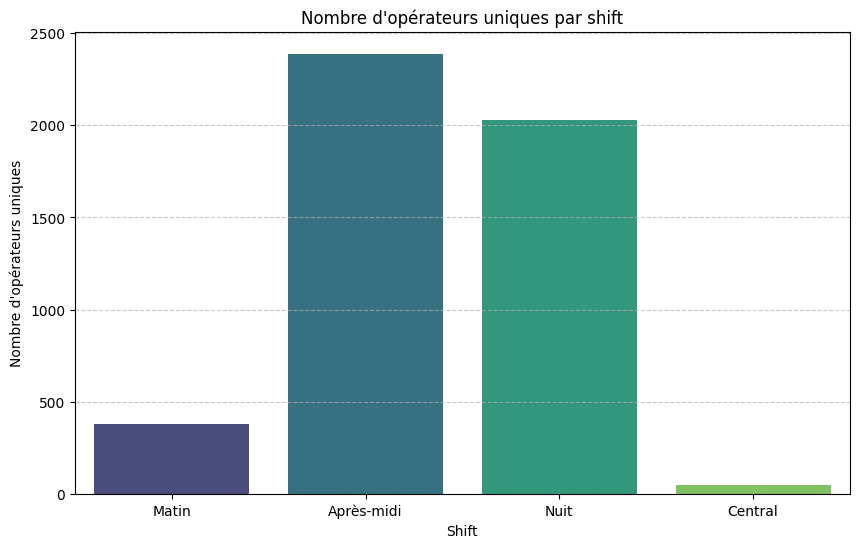

In [27]:


# Create a DataFrame for visualization
shift_counts = {
    'Matin': nombre_operateurs_matin,
    'Après-midi': nombre_operateurs_apres_midi,
    'Nuit': nombre_operateurs_nuit,
    'Central': n_operators_central_specific_times
}

shift_df = pd.DataFrame(shift_counts.items(), columns=['Shift', 'Number of Operators'])

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Shift', y='Number of Operators', data=shift_df, hue='Shift', palette='viridis', legend=False)
plt.title("Nombre d'opérateurs uniques par shift")
plt.xlabel('Shift')
plt.ylabel("Nombre d'opérateurs uniques")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Représentation visuelle de la répartition des opérateurs dans les systèmes à deux et trois équipes





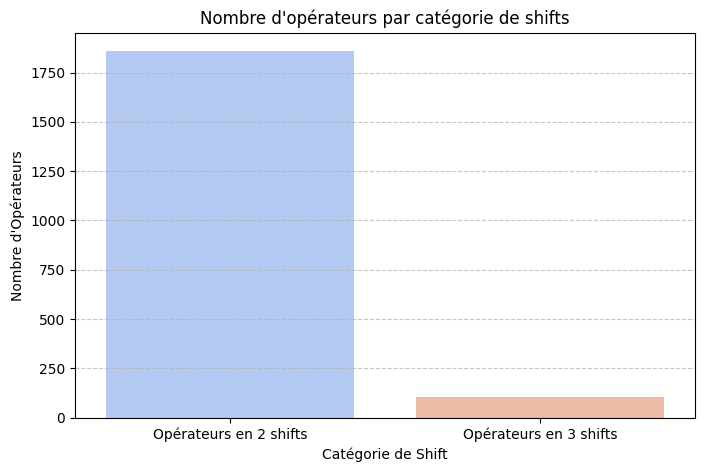

In [28]:


# Prepare data for visualization
shifts_comparison_data = {
    'Catégorie': ['Opérateurs en 2 shifts', 'Opérateurs en 3 shifts'],
    'Nombre d\'Opérateurs': [nombre_operateurs_2_shifts, nombre_operateurs_3_shifts]
}
shifts_comparison_df = pd.DataFrame(shifts_comparison_data)

# Create the bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Catégorie', y='Nombre d\'Opérateurs', data=shifts_comparison_df, hue='Catégorie', palette='coolwarm', legend=False)
plt.title("Nombre d'opérateurs par catégorie de shifts")
plt.xlabel('Catégorie de Shift')
plt.ylabel("Nombre d'Opérateurs")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

nombre d'opérateurs qui ont travaillé:
Matin et après-midi/
matin et nuit/
Après-midi et nuit


In [29]:

# Assuming operateurs_matin, operateurs_apres_midi, operateurs_nuit, and operateurs_3_shifts are already defined as sets.
# If not, they would need to be re-calculated based on the previous steps.

# Operators working in Morning AND Afternoon (excluding those in 3 shifts)
matin_apres_midi = operateurs_matin.intersection(operateurs_apres_midi)
operateurs_matin_apres_midi_seul = matin_apres_midi - operateurs_3_shifts
nombre_matin_apres_midi = len(operateurs_matin_apres_midi_seul)

# Operators working in Morning AND Night (excluding those in 3 shifts)
matin_nuit = operateurs_matin.intersection(operateurs_nuit)
operateurs_matin_nuit_seul = matin_nuit - operateurs_3_shifts
nombre_matin_nuit = len(operateurs_matin_nuit_seul)

# Operators working in Afternoon AND Night (excluding those in 3 shifts)
apres_midi_nuit = operateurs_apres_midi.intersection(operateurs_nuit)
operateurs_apres_midi_nuit_seul = apres_midi_nuit - operateurs_3_shifts
nombre_apres_midi_nuit = len(operateurs_apres_midi_nuit_seul)

print(f"Nombre d'opérateurs uniques travaillant le matin et l'après-midi (seulement 2 shifts) : {nombre_matin_apres_midi}")
print(f"Nombre d'opérateurs uniques travaillant le matin et la nuit (seulement 2 shifts) : {nombre_matin_nuit}")
print(f"Nombre d'opérateurs uniques travaillant l'après-midi et la nuit (seulement 2 shifts) : {nombre_apres_midi_nuit}")


Nombre d'opérateurs uniques travaillant le matin et l'après-midi (seulement 2 shifts) : 78
Nombre d'opérateurs uniques travaillant le matin et la nuit (seulement 2 shifts) : 0
Nombre d'opérateurs uniques travaillant l'après-midi et la nuit (seulement 2 shifts) : 1781


Répartition des Opérateurs par Type de Combinaison de Shift

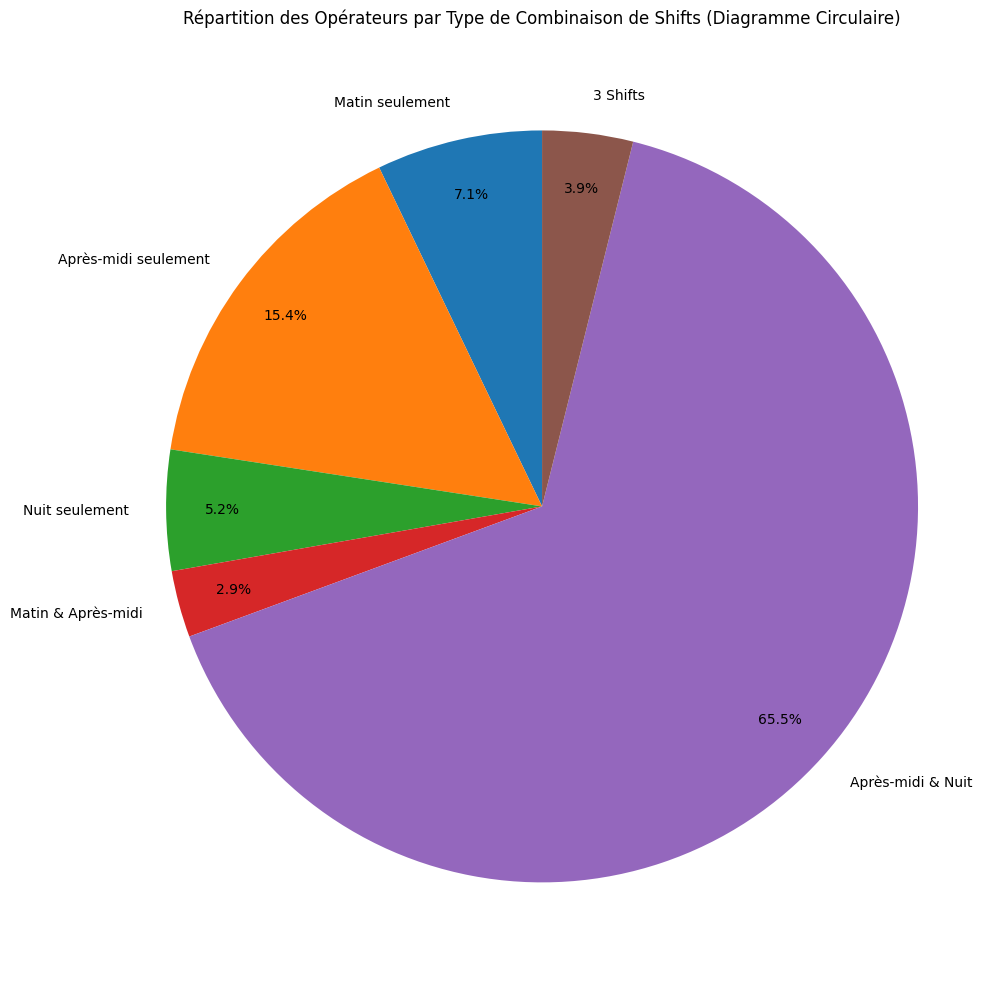

In [ ]:
# Calculate operators for 'central' shift
operateurs_central = set(operateurs_df[operateurs_df['shift '].str.lower() == 'central']['Mat.'].unique())

# Calculate operators working only in Central shift, excluding those in Matin, Après-midi, or Nuit
# This assumes 'operateurs_matin', 'operateurs_apres_midi', 'operateurs_nuit' are already defined as sets.
operateurs_central_seul = operateurs_central - (operateurs_matin | operateurs_apres_midi | operateurs_nuit)
nombre_central_seul = len(operateurs_central_seul)

# Calculate operators working only in a single shift
# Use the already defined sets: operateurs_matin, operateurs_apres_midi, operateurs_nuit, operateurs_3_shifts

# Operators working ONLY in Morning
nombre_matin_seul = len(operateurs_matin - (operateurs_apres_midi | operateurs_nuit))

# Operators working ONLY in Afternoon
nombre_apres_midi_seul = len(operateurs_apres_midi - (operateurs_matin | operateurs_nuit))

# Operators working ONLY in Night
nombre_nuit_seul = len(operateurs_nuit - (operateurs_matin | operateurs_apres_midi))


# Prepare data for detailed shift combination visualization
shift_combinations_data = {
    'Combinaison de Shifts': [
        'Matin seulement',
        'Après-midi seulement',
        'Nuit seulement',
        'Central seulement', 
        'Matin & Après-midi',
        'Matin & Nuit',
        'Après-midi & Nuit',
        '3 Shifts'
    ],
    'Nombre d\'Opérateurs': [
        nombre_matin_seul,
        nombre_apres_midi_seul,
        nombre_nuit_seul,
        nombre_central_seul, 
        nombre_matin_apres_midi,
        nombre_matin_nuit,
        nombre_apres_midi_nuit,
        nombre_operateurs_3_shifts
    ]
}

shift_combinations_df = pd.DataFrame(shift_combinations_data)

# Filter out combinations with 0 operators for cleaner pie chart (optional, but good practice)
shift_combinations_df = shift_combinations_df[shift_combinations_df["Nombre d'Opérateurs"] > 0]

# Create the pie chart
plt.figure(figsize=(10, 10))
plt.pie(shift_combinations_df["Nombre d'Opérateurs"],
        labels=shift_combinations_df['Combinaison de Shifts'],
        autopct='%1.1f%%', # Format for displaying percentages
        startangle=90, # Start the first slice at 90 degrees (top)
        pctdistance=0.85 # Distance of percentage labels from the center
       )

plt.title("Répartition des Opérateurs par Type de Combinaison de Shifts (Diagramme Circulaire)")
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

le nombre de bus par shift

In [31]:
nombre_bus_par_shift = operateurs_df.groupby('shift ')['BUS2'].nunique()
print("Nombre de bus uniques par shift :")
display(nombre_bus_par_shift)

Nombre de bus uniques par shift :


,BUS2
shift,
après midi,18
central,7
matin,13
nuit,22


Pourcentage de bus par shift

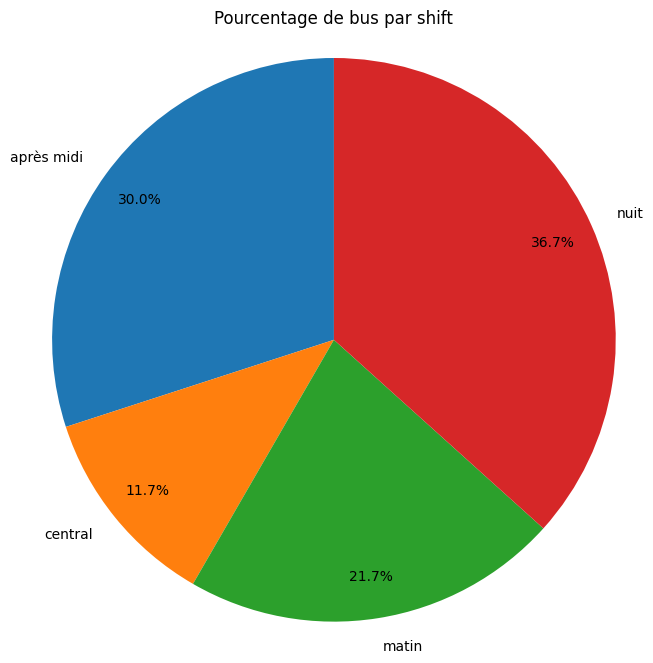

In [32]:
# Assuming nombre_bus_par_shift is already calculated
# nombre_bus_par_shift = operateurs_df.groupby('shift ')['BUS2'].nunique()

# Filter out any shifts with 0 buses if they exist for cleaner visualization
buses_per_shift_filtered = nombre_bus_par_shift[nombre_bus_par_shift > 0]

plt.figure(figsize=(8, 8))
plt.pie(buses_per_shift_filtered,
        labels=buses_per_shift_filtered.index,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.85)
plt.title('Pourcentage de bus par shift')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [33]:
output_file_path = '/content/drive/MyDrive/operateurs_df_cleaned.csv'
operateurs_df.to_csv(output_file_path, index=False)
print(f"Cleaned DataFrame saved to: {output_file_path}")

Cleaned DataFrame saved to: /content/drive/MyDrive/operateurs_df_cleaned.csv
